## 1. Linear Regression Example

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

# Coefficients
print("\nIntercept:", lr.intercept_)
print("Coefficients:", lr.coef_)
print("__" * 75)

R² Score: 0.4526027629719197
RMSE: 53.85344583676592

Intercept: 151.34560453985995
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
______________________________________________________________________________________________________________________________________________________


## 2. SGDRegressor Example

### GDRegressor learns using Stochastic Gradient Descent instead of solving the normal equation directly.

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create model
sgd = SGDRegressor(
    loss='squared_error',      # Loss function
    max_iter=2000,             # Maximum number of epochs
    eta0=0.1,                  # Initial learning rate
    penalty='elasticnet',      # Regularization type: 'l2' = Ridge, 'l1' = Lasso, 'elasticnet' = Mix of both
    l1_ratio=0.3,              # ElasticNet mixing parameter
    alpha=0.1,                 # Regularization strength
    learning_rate='optimal',   # Learning rate schedule
    tol=1e-3,                  # Stop training when improvement becomes smaller than this value
    early_stopping=True,       # Use part of training data as validation set and stop if validation score stops improving
    validation_fraction=0.1,   # Percentage of training data reserved for validation
    n_iter_no_change=5,        # Number of consecutive iterations without improvement before stopping training
    random_state=42            # Ensures reproducible results
)

# Train model
sgd.fit(X_train_scaled, y_train)

# Predictions
y_pred = sgd.predict(X_test_scaled)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

# Parameters learned
print("\nIntercept:", sgd.intercept_)
print("Coefficients:", sgd.coef_)
print("__" * 75)

R² Score: -677165.2244333338
RMSE: 59897.65785085301

Intercept: [3590.25000288]
Coefficients: [   5444.43776517    2499.56227061   10833.41073788   -3097.72474137
  533566.71282039 -431060.19064829 -222041.96475253  -49978.9032222
 -212640.63298271    3593.21970229]
______________________________________________________________________________________________________________________________________________________


# 3. Binary Logistic Regression Example

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load and Split Data
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)


# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
log_reg = LogisticRegression(
    solver='lbfgs',      # Optimization algorithm used to find the best coefficients
    penalty='l2',        # L2 regularization to reduce overfitting
    C=1.0,               # Inverse of regularization strength (smaller C = stronger regularization)
    max_iter=1000,       # Maximum number of optimization iterations
    random_state=42,     # Controls randomness (used by some solvers)
    tol=1e-3             # Convergence threshold; training stops when improvement is below this value
)


# Train Model
log_reg.fit(X_train_scaled, y_train)


# Predictions
y_pred = log_reg.predict(X_test_scaled)


# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Notes
"""
Alternative:
SGDClassifier(loss='log_loss')
- Faster on very large datasets.
- Supports online learning (partial_fit).
- Uses Stochastic Gradient Descent instead of full-batch optimization.
"""
print("__" * 75)

Accuracy: 0.9825

Confusion Matrix:
[[42  1]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

______________________________________________________________________________________________________________________________________________________


# 4. Multinomial Logistic Regression Example

In [4]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

# Multinomial Logistic Regression
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Predict class probabilities
y_prob = model.predict_proba(X_test)  # Probability for each class

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Show probabilities for the first 5 samples
df_probs = pd.DataFrame(
    y_prob,
    columns=iris.target_names
)

print("\nFirst 5 Probability Predictions:")
print(df_probs.head())
print("__" * 75)

Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


First 5 Probability Predictions:
     setosa  versicolor     virginica
0  0.985318    0.014682  4.623257e-08
1  0.001376    0.390954  6.076701e-01
2  0.186891    0.808905  4.203825e-03
3  0.155868    0.839902  4.230808e-03
4  0.988258    0.011742  3.539965e-08
______________________________________________________________________________________________________________________________________________________


# 5. K-Nearest Neighbors (KNN) Example

In [5]:
# Practical example for using KNN
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# load the data and split it
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state=42)

# standardlization
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Check the accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"\nClassification Reprot:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 1.0

Classification Reprot:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 6. Naive Bayes Example

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

# Gaussian Naive Bayes
model = GaussianNB(
    var_smoothing=1e-9   # Small value added to variances for numerical stability
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("__" * 75)

Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

______________________________________________________________________________________________________________________________________________________


# 7. Support Vector Classifier (SVC) Example

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Support Vector Machine
model = SVC(
    kernel='linear',     # Type of decision boundary (linear, rbf, poly, sigmoid)
    C=1.0,               # Controls the trade-off between margin size and classification errors
    gamma='scale',       # Controls influence of individual training samples (used in rbf/poly/sigmoid)
    probability=True,    # Enables probability predictions using predict_proba()
    random_state=42      # Controls randomness when probability=True
    # degree=3,          # Degree of polynomial kernel (only for kernel='poly')
    # coef0=0.0          # Independent term for poly and sigmoid kernels
)

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("__" * 75)

Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

______________________________________________________________________________________________________________________________________________________


# 8. Support Vector Regressor (SVR) Example

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
data = load_diabetes()

X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,      # Use 80% of data for training
    random_state=42      # Ensures reproducible train-test split
)

# Feature scaling (important for SVR)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Support Vector Regression
model = SVR(
    kernel='rbf',        # Type of regression function (linear, rbf, poly, sigmoid)
    C=100.0,             # Controls flexibility of the regression model
    epsilon=10.0,        # Width of the error margin where no penalty is applied
    gamma='scale'        # Controls influence of individual training samples
    # degree=3,          # Degree of polynomial kernel (only for kernel='poly')
    # coef0=0.0          # Independent term for poly and sigmoid kernels
)

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print("__" * 75)

MAE: 40.01
MSE: 2648.37
RMSE: 51.46
R² Score: 0.5001
______________________________________________________________________________________________________________________________________________________


# 9. Decision Tree Classifier Example

Accuracy: 0.6333333333333333
First fearture used for split:  petal length (cm)


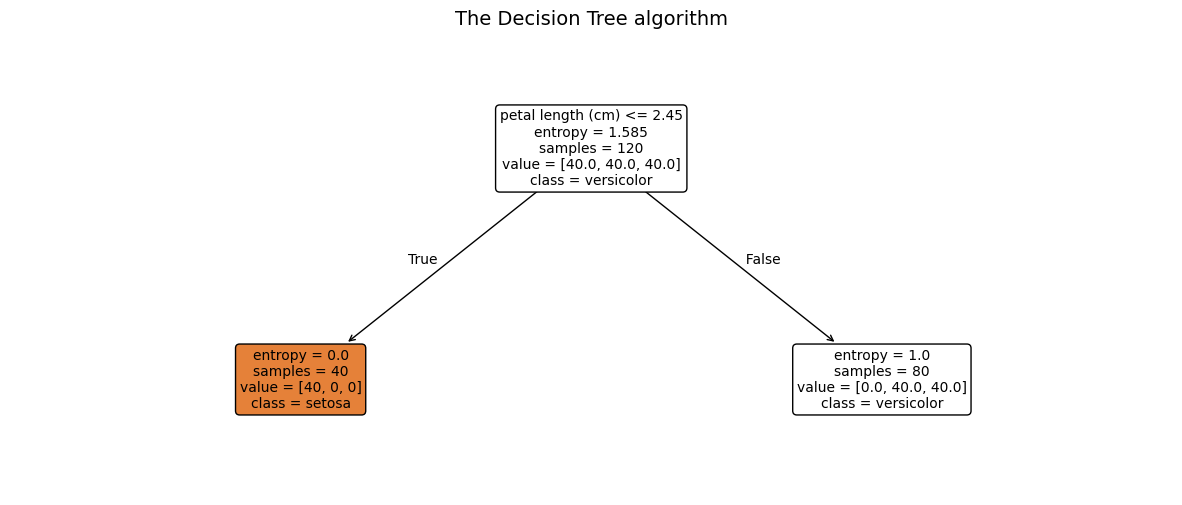

______________________________________________________________________________________________________________________________________________________


In [9]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# prepare the data and split it
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',     # Measure split quality using Information Gain (Entropy)
    max_features='sqrt',     # Consider only sqrt(number of features) at each split
    max_depth=3,             # Maximum tree depth
    splitter='best',         # Choose the best split among all candidates
    min_samples_split=2,     # Minimum samples required to split a node
    min_samples_leaf=1,      # Minimum samples required in a leaf node
    class_weight='balanced', # Automatically balance class weights
    ccp_alpha=0.5,           # Cost Complexity Pruning parameter,  Larger values = more aggressive pruning
    max_leaf_nodes=16,       # Maximum number of leaf nodes
    random_state= 42
)

# Train the data
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# check the accuracy and find the first feature
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")
print("First fearture used for split: ", iris.feature_names[model.tree_.feature[0]])

# plot the tree
plt.figure(figsize=(15, 6))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("The Decision Tree algorithm", fontsize=14)
plt.show()
print("__" * 75)

# 10. Decision Tree Regressor Example

R² Score: 0.30772341064054265
RMSE: 60.562252454577
First feature used for split: bmi


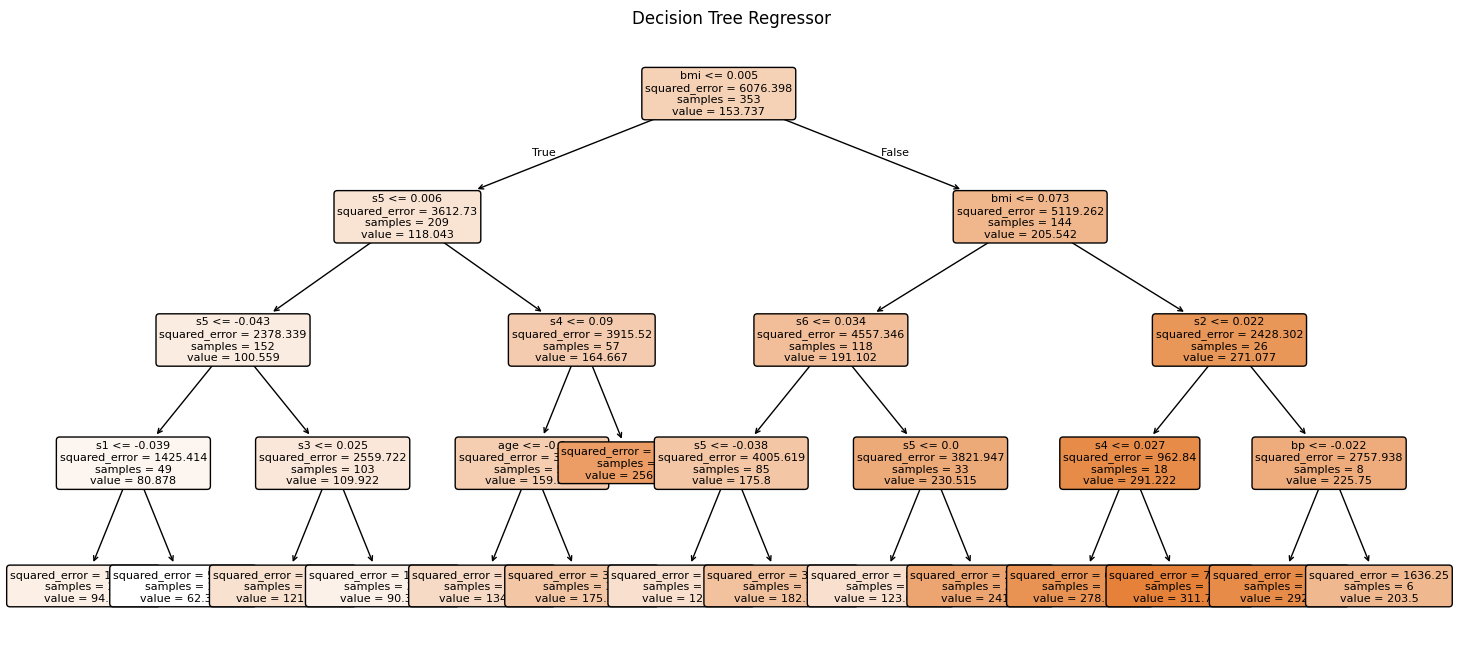

In [10]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Decision Tree Regressor
model = DecisionTreeRegressor(
    criterion='squared_error',  # MSE split criterion
    max_depth=4,                # Maximum tree depth
    min_samples_split=5,        # Minimum samples to split a node
    min_samples_leaf=2,         # Minimum samples in a leaf
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R² Score:", r2)
print("RMSE:", rmse)

# First feature used at the root node
print(
    "First feature used for split:",
    diabetes.feature_names[model.tree_.feature[0]]
)

# Plot tree
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=diabetes.feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Regressor")
plt.show()

# 11. Random Forest Example

In [11]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# prepare the data and split it
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(
    n_estimators=100,     # Number of trees in the forest
    max_depth=3,          # Maximum depth of each tree
    criterion='gini',     # Split criterion
    min_samples_split=10, # Minimum samples required to split a node
    min_samples_leaf=5,   # Minimum samples required in a leaf node
    bootstrap=True,       # Train each tree on a bootstrap sample, (random sampling with replacement)
    oob_score=True,       # Calculate Out-Of-Bag score using samples, # not selected during bootstrapping
    n_jobs=-1,            # Use all CPU cores
    max_features='sqrt',  # Number of features selected
    random_state=42,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# check the accuracy and find the first feature
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")
print("OOB Score:", model.oob_score_)

for feature, importance in zip(iris.feature_names, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")
print("__" * 75)

Accuracy: 1.0
OOB Score: 0.9416666666666667
sepal length (cm): 0.1082
sepal width (cm): 0.0097
petal length (cm): 0.4473
petal width (cm): 0.4349
______________________________________________________________________________________________________________________________________________________


# 12. Gradient Boosting Example

In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Prepare the data and split it
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

gbr = GradientBoostingRegressor(
    n_estimators=100,         # Number of weak learners (trees)
    learning_rate=0.1,        # Shrinks each tree's contribution
    max_depth=3,              # Maximum depth of each tree
    subsample=1,              # Fraction of samples used to train each tree
    tol=1e-3,                 # Minimum improvement required to continue training
    min_samples_split=10,     # Minimum samples required to split a node
    min_samples_leaf=5,       # Minimum samples required in a leaf node
    max_features='sqrt',      # Number of features considered at each split
    n_iter_no_change=50,      # Early stopping: stop if validation score doesn't improve
    random_state=42,
)


# Train the model
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# check the accuracy MSE
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
print(f"Gradient Boosting MSE: {mse_gbr:.4f}")
print("__" * 75)

Gradient Boosting MSE: 0.3226
______________________________________________________________________________________________________________________________________________________


# 13. Adaptive Boosting Example

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Prepare the data and split it
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# base model and AdaBoosting
base_model = DecisionTreeClassifier(max_depth=1)
ada = AdaBoostClassifier(estimator= base_model, n_estimators=50, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

# check the accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"__" * 75)

Accuracy: 0.956140350877193
______________________________________________________________________________________________________________________________________________________


# 14. XGboost Example

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Regressor
model = XGBRegressor(
    n_estimators=100,              # Number of boosting trees
    learning_rate=0.1,             # Step size shrinkage
    max_depth=3,                   # Maximum depth of each tree
    subsample=0.8,                 # Fraction of rows used for each tree
    colsample_bytree=0.8,          # Fraction of features used for each tree
    scale_pos_weight=9,            # Control imbalnce, scale_pos_weight = (# negative samples) / (# positive samples)
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("__" * 75)

R² Score: 0.43040942541965044
RMSE: 54.934299837637454
______________________________________________________________________________________________________________________________________________________


# 15. LightBGM Example

In [15]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

# Load data
X, y = load_diabetes(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# LightGBM Regressor
model = LGBMRegressor(
    n_estimators=100,     # Number of boosting trees
    learning_rate=0.1,    # Contribution of each tree
    max_depth=5,          # Maximum tree depth
    num_leaves=31,        # Maximum number of leaves in a tree
    subsample=0.8,        # Fraction of rows sampled for each tree
    colsample_bytree=0.8, # Fraction of columns sampled for each tree
    reg_alpha=0.0,        # L1 regularization
    reg_lambda=0.0,       # L2 regularization
    random_state=42,
    class_weight= 'balanced', # imbalance
    force_col_wise = True
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("__" * 75)

[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 353, number of used features: 10
[LightGBM] [Info] Start training from score 163.748744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

# 16. Stacking Example

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# prepare the data and split
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# prepare the base models
base_models = [
    ('lr',
     LogisticRegression(max_iter=1000)),
    ('knn',
     KNeighborsClassifier(n_neighbors=5)),
    ('tree',
     DecisionTreeClassifier(max_depth=4))
]

# prepare the metal model and stack model
meta_model = RandomForestClassifier(n_estimators=100, random_state=42)
stack_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True, cv=5)

stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)

# check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("__" * 75)

Accuracy: 1.000
______________________________________________________________________________________________________________________________________________________


# 17. Principal Component Analysis (PCA) Example

In [17]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# prepare the data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# standarization
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

# PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

# show the total information (variance) kept
print(f"Explanied variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance kept: {sum(pca.explained_variance_ratio_)}")
print("__" * 75)

Explanied variance ratio: [0.72962445 0.22850762]
Total variance kept: 0.9581320720000166
______________________________________________________________________________________________________________________________________________________


# 18.Another Dimensionally Reduction Example

In [18]:
from sklearn.datasets import load_iris
from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.manifold import LocallyLinearEmbedding

# Load data
X, y = load_iris(return_X_y=True)

#============================================
# Kernel PCA
#============================================
kpca = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=0.1
)

X_kpca = kpca.fit_transform(X)

print(X_kpca.shape)
print(X_kpca[:5])
print("==" * 50)

#============================================
# LDA
#============================================
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X, y)

print(X_lda.shape)
print(X_lda[:5])
print("==" * 50)

#============================================
# t-SNE
#============================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

print(X_tsne.shape)
print(X_tsne[:5])
print("==" * 50)

#============================================
# LLE
#============================================
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=10
)

X_lle = lle.fit_transform(X)

print(X_lle.shape)
print(X_lle[:5])
print("==" * 50)

(150, 2)
[[0.77069596 0.09584297]
 [0.75985966 0.06640555]
 [0.77865111 0.11157793]
 [0.75767156 0.06693483]
 [0.77430245 0.10791579]]
(150, 2)
[[ 8.06179978 -0.30042062]
 [ 7.12868772  0.78666043]
 [ 7.48982797  0.26538449]
 [ 6.81320057  0.67063107]
 [ 8.13230933 -0.51446253]]
(150, 2)
[[-25.50239    -1.6439273]
 [-23.042055   -0.9945823]
 [-22.78724    -2.0969117]
 [-22.4982     -1.8618948]
 [-25.574633   -2.148222 ]]
(150, 2)
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


# 19. K-Means Example

In [19]:
# practical example for using K-Means
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.cluster import KMeans

# prepare the data
data = load_iris()
X = data.data

# K-means
kmeans = KMeans(
    n_clusters=3,     # Number of clusters to create
    max_iter=300,     # Maximum number of iterations
    init='k-means++', # Method for choosing initial centroids, 'k-means++' is usually the best choice
    tol=1e-3,         # Stop when centroid movement becomes very small
    n_init=10,        # Number of different centroid initializations, # Best result is kept
    random_state=42,
)

# Train the model
kmeans.fit(X)
labels = kmeans.labels_

# make the dataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['cluster'] = labels

# check the results
score = silhouette_score(X, labels)
print(df.head())
print("\nCluster centers: \n", kmeans.cluster_centers_)
print(f"\nSilhousette Score: {score:.3f}")
print("__" * 75)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  

Cluster centers: 
 [[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]

Silhousette Score: 0.553
______________________________________________________________________________________________________________________________________________________


# 20. Hierarchical Clustering Example

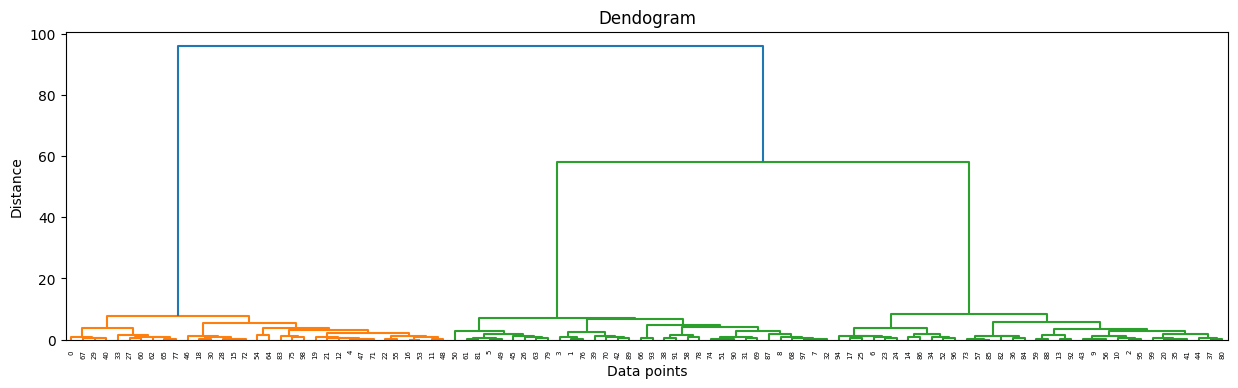

In [20]:
# Practical example for using agglomerative clustering
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# generate a random data
X, y = make_blobs(n_samples=100, centers=3, random_state=42, cluster_std=1.2)

# Aggolomerative Clusering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

# Draw a Dendogram to know the relations between points
plt.figure(figsize=(15, 4))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

# 21. DBSCAN Example

silhouette score: 0.2724927634081228


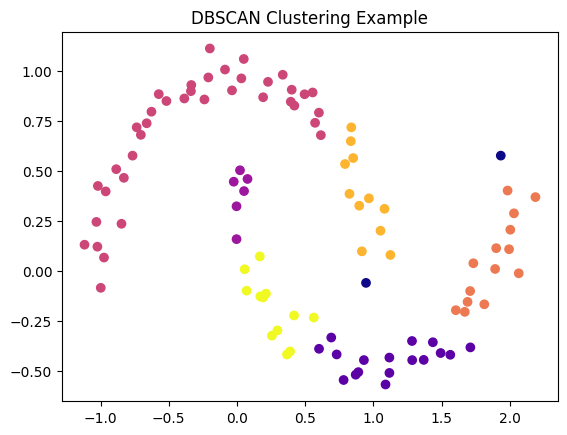

In [21]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Generate data
X, y = make_moons(n_samples=100, noise=0.07, random_state=42)

# DBSCAN
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

# get the silhousette score
print(f"silhouette score: {silhouette_score(X, labels)}")

# plot the results
plt.scatter(X[:,0], X[:,1], c=labels, cmap='plasma')
plt.title("DBSCAN Clustering Example")
plt.show()

# 22. Neural Network Example

In [22]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# One-hot encoding
y = to_categorical(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(3, activation='softmax')
])

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_split=0.3,
    callbacks=[early_stopping],
    verbose=1
)

# Predict probabilities
predictions = model.predict(X_test)

# Predicted class
predicted_classes = np.argmax(predictions, axis=1)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Accuracy: {accuracy:.4f}")

# Summary
model.summary()

# Save model
"""model.save("iris_model.keras")"""

# Load model
"""loaded_model = load_model("iris_model.keras")"""

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.2143 - loss: 1.5029 - val_accuracy: 0.2778 - val_loss: 1.3240
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2143 - loss: 1.4688 - val_accuracy: 0.2778 - val_loss: 1.3014
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2143 - loss: 1.4329 - val_accuracy: 0.3333 - val_loss: 1.2792
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2143 - loss: 1.3990 - val_accuracy: 0.3333 - val_loss: 1.2573
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2262 - loss: 1.3635 - val_accuracy: 0.3333 - val_loss: 1.2359
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2381 - loss: 1.3326 - val_accuracy: 0.3611 - val_loss: 1.2145
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2381 - loss: 1.2999 - val_accuracy: 0.3611 - val_loss: 1.1936
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2500 - loss: 1.2701 - val_accuracy: 0.3611 - val_loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203 (816.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 136 (548.00 B)

'loaded_model = load_model("iris_model.keras")'

# 23. Machine Learning Pipeline Example

accuracy: 0.9385964912280702
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
 [[39  3]
 [ 4 68]]
CV F1: 0.961 (+/- 0.028)


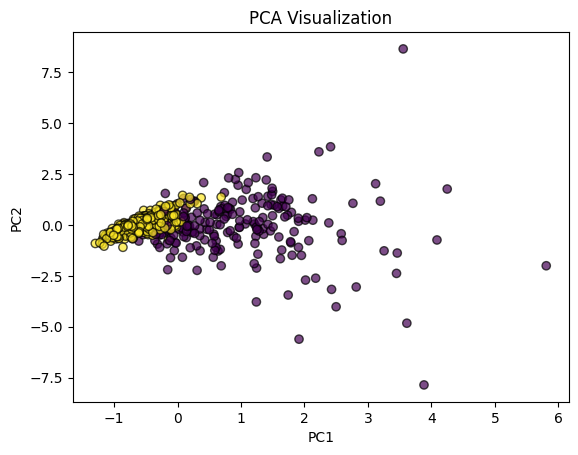

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['hospital'] = np.random.choice(['A', 'B', 'C'], size=len(df))
mask = np.random.random(df.shape) < 0.05
df.values[mask] = np.nan
X, y = df.values, data.target

# 2. Determine the columns
categorical_cols = [df.shape[1] - 1]
numeric_cols = list(range(df.shape[1] - 1))

# 3. Preprocessor
preprocessor = ColumnTransformer([
    ('impute_num', KNNImputer(n_neighbors=5), numeric_cols),
    ('encode_cat', OneHotEncoder(drop='first'), categorical_cols)
])

# 4. Complete pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('pca', PCA(n_components=5)),
    ('scale', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

# 5. train and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)

# 6. Full Report 
print("accuracy:", pipeline.score(X_test, y_test))
print(classification_report(y_test, pipeline.predict(X_test), target_names=['malignant', 'benign']))
print("Confusion Matrix:\n", confusion_matrix(y_test, pipeline.predict(X_test)))

# 7. Cross Validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
print(f"CV F1: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

# 8. Draw PCA
pca_vis = Pipeline([
    ('prep', preprocessor),
    ('pca', PCA(n_components=2)),
    ('scale', StandardScaler())
])
X_pca = pca_vis.fit_transform(X, y)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA Visualization')
plt.show()